In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
import sys
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("所有库导入成功！")

所有库导入成功！


In [4]:
def check_files():
    """检查所有数据文件是否存在"""
    files_info = {
        "../AMOS20200313/VIS_R06_12.his": "能见度数据文件",
        "../AMOS20200313/PTU_R06_12.his": "气象数据文件", 
        "../AMOS20200313/WIND_R06_12.his": "风速数据文件",
        "../机场视频/a.mp4": "机场视频文件(可选)"
    }
    
    print("=" * 50)
    print("数据文件检查结果:")
    print("=" * 50)
    
    existing_files = []
    missing_files = []
    
    for filename, description in files_info.items():
        if os.path.exists(filename):
            file_size = os.path.getsize(filename)
            print(f"✓ {filename:20s} - {description} ({file_size:,} bytes)")
            existing_files.append(filename)
        else:
            print(f"✗ {filename:20s} - {description} (文件不存在)")
            missing_files.append(filename)
    
    print(f"\n存在的文件: {len(existing_files)} 个")
    print(f"缺失的文件: {len(missing_files)} 个")
    
    return existing_files, missing_files

# 执行文件检查
existing_files, missing_files = check_files()

数据文件检查结果:
✓ ../AMOS20200313/VIS_R06_12.his - 能见度数据文件 (1,700,858 bytes)
✓ ../AMOS20200313/PTU_R06_12.his - 气象数据文件 (193,748 bytes)
✓ ../AMOS20200313/WIND_R06_12.his - 风速数据文件 (916,086 bytes)
✓ ../机场视频/a.mp4        - 机场视频文件(可选) (1,042,173,258 bytes)

存在的文件: 4 个
缺失的文件: 0 个


In [5]:
def load_and_analyze_vis_file(filename="../AMOS20200313/VIS_R06_12.his"):
    """加载并分析VIS文件"""
    if not os.path.exists(filename):
        print(f"错误: {filename} 文件不存在")
        return None
    
    print(f"正在分析 {filename}...")
    print("=" * 60)
    
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        print(f"文件总行数: {len(lines)}")
        print(f"前3行内容:")
        for i, line in enumerate(lines[:3]):
            print(f"第{i+1}行: {line.strip()}")
        
        # 分析数据行
        data_lines = []
        for i, line in enumerate(lines[1:], 1):  # 跳过第一行标题
            if line.strip() and not line.startswith('History'):
                parts = line.strip().split()
                if len(parts) >= 10:  # 确保有足够的列
                    data_lines.append((i+1, parts))
        
        print(f"\n有效数据行数: {len(data_lines)}")
        
        if data_lines:
            print(f"\n第一个数据行分析 (第{data_lines[0][0]}行):")
            parts = data_lines[0][1]
            print(f"  列数: {len(parts)}")
            print(f"  时间戳: {parts[1] if len(parts) > 1 else 'N/A'}")
            print(f"  前10列: {parts[:10]}")
            
            print(f"\n最后一个数据行分析 (第{data_lines[-1][0]}行):")
            parts = data_lines[-1][1]
            print(f"  时间戳: {parts[1] if len(parts) > 1 else 'N/A'}")
            
        return data_lines
        
    except Exception as e:
        print(f"读取文件时出错: {e}")
        return None

# 分析VIS文件
vis_data_lines = load_and_analyze_vis_file()

正在分析 ../AMOS20200313/VIS_R06_12.his...
文件总行数: 5757
前3行内容:
第1行: History file
第2行: CREATEDATE	LOCALDATE (BEIJING)	SITE	RVR1M	RVR_1A	ST	RVR1X	RVR_10M	RVR_10A	ST	RVR_10X	RVR_TEND	MOR_1A	MOR_10M	MOR_10A	MOR_10X	VIS1K	VIS1A	VIS10A	BL1A	RVR DATA	MOR_RAW	VIS_RAW	LIGHTS	STATUS	RVR DATA
第3行: 2020-03-12 00:00:00	2020-03-12 08:00:00	R06	2800	3000	 	3000	2800	2900	 	3000	0	3000	2800	2900	3000	  1208	3000	3000	5461	3087	 3088	  3088	  100	00000000000000000000	VIS  3087.5 AL 00000000000000000000 BL 05461 AL 0 WMO // WMO15M // WMO60M // RN1M ////// RNSUM ////// SNSUM //// TMP ///// AL 0B17A

有效数据行数: 5756

第一个数据行分析 (第2行):
  列数: 29
  时间戳: LOCALDATE
  前10列: ['CREATEDATE', 'LOCALDATE', '(BEIJING)', 'SITE', 'RVR1M', 'RVR_1A', 'ST', 'RVR1X', 'RVR_10M', 'RVR_10A']

最后一个数据行分析 (第5757行):
  时间戳: 23:59:45


In [6]:
def load_and_analyze_ptu_file(filename="../AMOS20200313/PTU_R06_12.his"):
    """加载并分析PTU文件"""
    if not os.path.exists(filename):
        print(f"错误: {filename} 文件不存在")
        return None
    
    print(f"正在分析 {filename}...")
    print("=" * 60)
    
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        print(f"文件总行数: {len(lines)}")
        print(f"前5行内容:")
        for i, line in enumerate(lines[:5]):
            print(f"第{i+1}行: {line.strip()}")
        
        # 分析数据行（通常从第三行开始）
        data_lines = []
        for i, line in enumerate(lines[2:], 2):  # 从第三行开始
            if line.strip():
                parts = line.strip().split('\t')  # PTU文件通常用tab分隔
                if len(parts) >= 5:
                    data_lines.append((i+1, parts))
        
        print(f"\n有效数据行数: {len(data_lines)}")
        
        if data_lines:
            print(f"\n第一个数据行分析 (第{data_lines[0][0]}行):")
            parts = data_lines[0][1]
            print(f"  列数: {len(parts)}")
            print(f"  时间戳: {parts[1] if len(parts) > 1 else 'N/A'}")
            print(f"  前5列: {parts[:5]}")
            
            if len(parts) > 10:
                print(f"  温度相关列 (第13-16列): {parts[12:16] if len(parts) > 15 else parts[12:]}")
            
            print(f"\n最后一个数据行分析 (第{data_lines[-1][0]}行):")
            parts = data_lines[-1][1]
            print(f"  时间戳: {parts[1] if len(parts) > 1 else 'N/A'}")
            
        return data_lines
        
    except Exception as e:
        print(f"读取文件时出错: {e}")
        return None

# 分析PTU文件
ptu_data_lines = load_and_analyze_ptu_file()

正在分析 ../AMOS20200313/PTU_R06_12.his...
文件总行数: 1442
前5行内容:
第1行: History file
第2行: CREATEDATE	LOCALDATE (BEIJING)	SITE	PAINS (HPA)	QNH AERODROME (HPA)	ST	QFE R06 (HPA)	ST	QFE R24 (HPA)	ST	QFF AERODROME (HPA)	TREND	TENDENCY	TEMP (°C)	RH (%)	DEWPOINT (°C)	TU DATA
第3行: 2020-03-12 00:00:00	2020-03-12 08:00:00	R06	1016.90	1018.44	 	1016.88	 	1017.05	 	1018.47	 0.30	3	9.70	85.00	7.32	   9.7    85 81F6
第4行: 2020-03-12 00:01:00	2020-03-12 08:01:00	R06	1017.00	1018.54	 	1016.98	 	1017.15	 	1018.57	 0.30	3	9.80	85.00	7.42	   9.8    85 5834
第5行: 2020-03-12 00:02:00	2020-03-12 08:02:00	R06	1017.00	1018.54	 	1016.98	 	1017.15	 	1018.57	 0.30	3	9.80	84.00	7.24	   9.8    84 6B05

有效数据行数: 1440

第一个数据行分析 (第3行):
  列数: 17
  时间戳: 2020-03-12 08:00:00
  前5列: ['2020-03-12 00:00:00', '2020-03-12 08:00:00', 'R06', '1016.90', '1018.44']
  温度相关列 (第13-16列): ['3', '9.70', '85.00', '7.32']

最后一个数据行分析 (第1442行):
  时间戳: 2020-03-13 07:59:00


In [7]:
def load_and_analyze_wind_file(filename="../AMOS20200313/WIND_R06_12.his"):
    """加载并分析WIND文件"""
    if not os.path.exists(filename):
        print(f"错误: {filename} 文件不存在")
        return None
    
    print(f"正在分析 {filename}...")
    print("=" * 60)
    
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        print(f"文件总行数: {len(lines)}")
        print(f"前3行内容:")
        for i, line in enumerate(lines[:3]):
            print(f"第{i+1}行: {line.strip()}")
        
        # 分析数据行
        data_lines = []
        for i, line in enumerate(lines[1:], 1):  # 跳过第一行标题
            if line.strip() and not line.startswith('History'):
                parts = line.strip().split()
                if len(parts) >= 10:
                    data_lines.append((i+1, parts))
        
        print(f"\n有效数据行数: {len(data_lines)}")
        
        if data_lines:
            print(f"\n第一个数据行分析 (第{data_lines[0][0]}行):")
            parts = data_lines[0][1]
            print(f"  列数: {len(parts)}")
            print(f"  时间戳: {parts[1] if len(parts) > 1 else 'N/A'}")
            print(f"  前10列: {parts[:10]}")
            
            print(f"\n最后一个数据行分析 (第{data_lines[-1][0]}行):")
            parts = data_lines[-1][1]
            print(f"  时间戳: {parts[1] if len(parts) > 1 else 'N/A'}")
            
        return data_lines
        
    except Exception as e:
        print(f"读取文件时出错: {e}")
        return None

# 分析WIND文件
wind_data_lines = load_and_analyze_wind_file()

正在分析 ../AMOS20200313/WIND_R06_12.his...
文件总行数: 5757
前3行内容:
第1行: History file
第2行: CREATEDATE	LOCALDATE (BEIJING)	SITE	WSINS (MPS)	WS2M (MPS)	WS2A (MPS)	WS2X (MPS)	WS10M (MPS)	WS10A (MPS)	ST	WS10X (MPS)	WDINS	WD2M	WD2A	WD2X	WD10M	WD10A	ST	WD10X	GUST_SPEED (MPS)	GUST_DIR	WDVAR	CW2A (MPS)	ST	HW2A (MPS)	ST	HIGHWIND	HIGHWIND_TIME	STATUS	WIND DATA
第3行: 2020-03-12 00:00:00	2020-03-12 08:00:00	R06	1.20	1.00	1.47	2.00	0.70	1.58	 	2.50	75	43	70	83	19	59	 	94	2.50	55	0	0.31	 	1.44	 	0	 	A	71,R,1.2,M,A*04

有效数据行数: 5756

第一个数据行分析 (第2行):
  列数: 42
  时间戳: LOCALDATE
  前10列: ['CREATEDATE', 'LOCALDATE', '(BEIJING)', 'SITE', 'WSINS', '(MPS)', 'WS2M', '(MPS)', 'WS2A', '(MPS)']

最后一个数据行分析 (第5757行):
  时间戳: 23:59:45


In [8]:
def check_video_file(filename="../机场视频/a.mp4"):
    """检查视频文件信息"""
    print(f"检查视频文件: {filename}")
    print("=" * 40)
    
    if not os.path.exists(filename):
        print(f"视频文件 {filename} 不存在")
        return None
    
    try:
        # 获取文件大小
        file_size = os.path.getsize(filename)
        print(f"文件大小: {file_size:,} bytes ({file_size/1024/1024:.1f} MB)")
        
        # 尝试打开视频文件
        cap = cv2.VideoCapture(filename)
        
        if not cap.isOpened():
            print("无法打开视频文件")
            return None
        
        # 获取视频信息
        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        duration = frame_count / fps if fps > 0 else 0
        
        print(f"视频信息:")
        print(f"  分辨率: {width} x {height}")
        print(f"  帧率: {fps:.2f} FPS")
        print(f"  总帧数: {frame_count:,}")
        print(f"  时长: {duration:.1f} 秒 ({duration/60:.1f} 分钟)")
        
        # 读取第一帧作为测试
        ret, frame = cap.read()
        if ret:
            print(f"  成功读取第一帧，形状: {frame.shape}")
        else:
            print("  无法读取第一帧")
        
        cap.release()
        return {
            'fps': fps,
            'frame_count': frame_count,
            'width': width,
            'height': height,
            'duration': duration
        }
        
    except Exception as e:
        print(f"检查视频文件时出错: {e}")
        return None

# 检查视频文件
video_info = check_video_file()

检查视频文件: ../机场视频/a.mp4
文件大小: 1,042,173,258 bytes (993.9 MB)
视频信息:
  分辨率: 1280 x 720
  帧率: 25.00 FPS
  总帧数: 1,040,210
  时长: 41608.4 秒 (693.5 分钟)
  成功读取第一帧，形状: (720, 1280, 3)


In [9]:
def parse_vis_data():
    """解析VIS文件 - 基于实际格式"""
    print("解析VIS能见度数据...")
    
    vis_data = []
    with open("../AMOS20200313/VIS_R06_12.his", 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # 跳过前两行（标题行）
    for i, line in enumerate(lines[2:], 2):
        if line.strip():
            parts = line.strip().split('\t')
            try:
                # 根据您的输出，数据格式为：
                # [0]CREATEDATE [1]LOCALDATE [2]SITE [3]RVR1M [4]RVR_1A ... [12]MOR_1A ...
                data = {
                    'timestamp': parts[1],  # LOCALDATE (BEIJING)
                    'RVR_1A': float(parts[4]) if parts[4].strip() and parts[4].replace('.','').isdigit() else 0,
                    'MOR_1A': float(parts[12]) if len(parts) > 12 and parts[12].strip() and parts[12].replace('.','').isdigit() else 0,
                    'VIS1A': float(parts[17]) if len(parts) > 17 and parts[17].strip() and parts[17].replace('.','').isdigit() else 0,
                    'visibility': float(parts[12]) if len(parts) > 12 and parts[12].strip() and parts[12].replace('.','').isdigit() else 0  # 使用MOR_1A
                }
                
                # 只保留有效数据
                if data['visibility'] > 0:
                    vis_data.append(data)
                    
            except (ValueError, IndexError) as e:
                continue
    
    print(f"解析VIS数据: {len(vis_data)} 条有效记录")
    if vis_data:
        print(f"时间范围: {vis_data[0]['timestamp']} 到 {vis_data[-1]['timestamp']}")
        print(f"能见度范围: {min(d['visibility'] for d in vis_data):.1f}m 到 {max(d['visibility'] for d in vis_data):.1f}m")
    
    return vis_data

def parse_ptu_data():
    """解析PTU文件 - 基于实际格式"""
    print("解析PTU气象数据...")
    
    ptu_data = []
    with open("../AMOS20200313/PTU_R06_12.his", 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # 跳过前两行（标题行）
    for i, line in enumerate(lines[2:], 2):
        if line.strip():
            parts = line.strip().split('\t')
            try:
                # 根据您的输出，数据格式为：
                # [0]CREATEDATE [1]LOCALDATE [2]SITE [3]PAINS... [13]TEMP [14]RH [15]DEWPOINT
                data = {
                    'timestamp': parts[1],  # LOCALDATE (BEIJING)
                    'pressure': float(parts[3]) if parts[3].strip() and parts[3].replace('.','').replace('-','').isdigit() else 1013.25,
                    'temperature': float(parts[13]) if len(parts) > 13 and parts[13].strip() else 10.0,
                    'humidity': float(parts[14]) if len(parts) > 14 and parts[14].strip() else 80.0,
                    'dewpoint': float(parts[15]) if len(parts) > 15 and parts[15].strip() else 8.0
                }
                
                # 数据合理性检查
                if (0 <= data['humidity'] <= 100 and 
                    -50 <= data['temperature'] <= 50 and
                    950 <= data['pressure'] <= 1050):
                    ptu_data.append(data)
                    
            except (ValueError, IndexError) as e:
                continue
    
    print(f"解析PTU数据: {len(ptu_data)} 条有效记录")
    if ptu_data:
        print(f"时间范围: {ptu_data[0]['timestamp']} 到 {ptu_data[-1]['timestamp']}")
        print(f"温度范围: {min(d['temperature'] for d in ptu_data):.1f}°C 到 {max(d['temperature'] for d in ptu_data):.1f}°C")
        print(f"湿度范围: {min(d['humidity'] for d in ptu_data):.1f}% 到 {max(d['humidity'] for d in ptu_data):.1f}%")
    
    return ptu_data

def parse_wind_data():
    """解析WIND文件 - 基于实际格式"""
    print("解析WIND风速数据...")
    
    wind_data = []
    with open("../AMOS20200313/WIND_R06_12.his", 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # 跳过前两行（标题行）
    for i, line in enumerate(lines[2:], 2):
        if line.strip():
            parts = line.strip().split('\t')
            try:
                # 需要找到正确的列索引，根据标题行分析
                # 从您的输出看，大概是：WS2A, WD2A, CW2A等
                data = {
                    'timestamp': parts[1],  # LOCALDATE (BEIJING)
                    'wind_speed_2a': float(parts[5]) if len(parts) > 5 and parts[5].strip() and parts[5].replace('.','').isdigit() else 1.0,  # WS2A
                    'wind_direction_2a': float(parts[13]) if len(parts) > 13 and parts[13].strip() and parts[13].replace('.','').isdigit() else 180.0,  # WD2A
                    'vertical_wind_2a': float(parts[22]) if len(parts) > 22 and parts[22].strip() and parts[22].replace('.','').replace('-','').isdigit() else 0.0  # CW2A
                }
                
                # 数据合理性检查
                if (0 <= data['wind_speed_2a'] <= 50 and 
                    0 <= data['wind_direction_2a'] <= 360):
                    wind_data.append(data)
                    
            except (ValueError, IndexError) as e:
                continue
    
    print(f"解析WIND数据: {len(wind_data)} 条有效记录")
    if wind_data:
        print(f"时间范围: {wind_data[0]['timestamp']} 到 {wind_data[-1]['timestamp']}")
        print(f"风速范围: {min(d['wind_speed_2a'] for d in wind_data):.1f}m/s 到 {max(d['wind_speed_2a'] for d in wind_data):.1f}m/s")
    
    return wind_data

# 解析所有数据
print("开始解析所有数据文件...")
print("=" * 60)

vis_data = parse_vis_data()
print()
ptu_data = parse_ptu_data()
print()
wind_data = parse_wind_data()

开始解析所有数据文件...
解析VIS能见度数据...
解析VIS数据: 5739 条有效记录
时间范围: 2020-03-12 08:00:00 到 2020-03-13 07:59:45
能见度范围: 50.0m 到 10000.0m

解析PTU气象数据...
解析PTU数据: 1440 条有效记录
时间范围: 2020-03-12 08:00:00 到 2020-03-13 07:59:00
温度范围: 7.8°C 到 20.2°C
湿度范围: 35.0% 到 100.0%

解析WIND风速数据...
解析WIND数据: 5755 条有效记录
时间范围: 2020-03-12 08:00:00 到 2020-03-13 07:59:45
风速范围: 0.1m/s 到 4.7m/s


In [10]:
def merge_data_with_timestamp_matching():
    """合并数据 - 智能时间戳匹配"""
    print("开始数据合并...")
    
    # 创建时间戳索引
    ptu_dict = {record['timestamp']: record for record in ptu_data}
    wind_dict = {record['timestamp']: record for record in wind_data}
    
    merged_data = []
    exact_matches = 0
    fuzzy_matches = 0
    
    for vis_record in vis_data:
        timestamp = vis_record['timestamp']
        
        # 精确匹配
        ptu_record = ptu_dict.get(timestamp)
        wind_record = wind_dict.get(timestamp)
        
        # 如果精确匹配失败，尝试邻近匹配
        if not ptu_record:
            ptu_record = find_nearest_record(ptu_data, timestamp, max_diff_minutes=2)
        if not wind_record:
            wind_record = find_nearest_record(wind_data, timestamp, max_diff_seconds=30)
        
        if ptu_record and wind_record:
            if ptu_dict.get(timestamp) and wind_dict.get(timestamp):
                exact_matches += 1
            else:
                fuzzy_matches += 1
                
            combined_record = {
                'timestamp': timestamp,
                'visibility': vis_record['visibility'],
                'RVR_1A': vis_record['RVR_1A'],
                'MOR_1A': vis_record['MOR_1A'],
                'temperature': ptu_record['temperature'],
                'humidity': ptu_record['humidity'],
                'pressure': ptu_record['pressure'],
                'dewpoint': ptu_record['dewpoint'],
                'wind_speed': wind_record['wind_speed_2a'],
                'wind_direction': wind_record['wind_direction_2a'],
                'vertical_wind': wind_record['vertical_wind_2a']
            }
            merged_data.append(combined_record)
    
    print(f"合并结果:")
    print(f"  精确匹配: {exact_matches} 条")
    print(f"  邻近匹配: {fuzzy_matches} 条")
    print(f"  总计: {len(merged_data)} 条有效记录")
    print(f"  合并成功率: {len(merged_data)/len(vis_data)*100:.1f}%")
    
    return merged_data

def find_nearest_record(data_list, target_timestamp, max_diff_minutes=None, max_diff_seconds=None):
    """查找最近时间的记录"""
    try:
        target_time = datetime.strptime(target_timestamp, '%Y-%m-%d %H:%M:%S')
    except:
        return None
    
    best_record = None
    min_diff = float('inf')
    
    # 设置最大时间差
    if max_diff_minutes:
        max_diff_total = max_diff_minutes * 60
    elif max_diff_seconds:
        max_diff_total = max_diff_seconds
    else:
        max_diff_total = 300  # 默认5分钟
    
    for record in data_list:
        try:
            record_time = datetime.strptime(record['timestamp'], '%Y-%m-%d %H:%M:%S')
            diff_seconds = abs((target_time - record_time).total_seconds())
            
            if diff_seconds < min_diff and diff_seconds <= max_diff_total:
                min_diff = diff_seconds
                best_record = record
        except:
            continue
    
    return best_record

# 执行数据合并
merged_data = merge_data_with_timestamp_matching()

开始数据合并...
合并结果:
  精确匹配: 1437 条
  邻近匹配: 4302 条
  总计: 5739 条有效记录
  合并成功率: 100.0%


In [11]:
def analyze_merged_data():
    """分析合并后的数据质量"""
    print("数据质量分析...")
    print("=" * 50)
    
    if not merged_data:
        print("没有合并的数据可供分析")
        return
    
    # 基本统计
    print(f"数据概况:")
    print(f"  总记录数: {len(merged_data)}")
    print(f"  时间跨度: {merged_data[0]['timestamp']} 到 {merged_data[-1]['timestamp']}")
    
    # 提取数值数据
    visibility = [d['visibility'] for d in merged_data]
    temperature = [d['temperature'] for d in merged_data]
    humidity = [d['humidity'] for d in merged_data]
    wind_speed = [d['wind_speed'] for d in merged_data]
    
    print(f"\n各变量统计:")
    print(f"  能见度: {np.mean(visibility):.1f}±{np.std(visibility):.1f}m (范围: {np.min(visibility):.1f}-{np.max(visibility):.1f}m)")
    print(f"  温度: {np.mean(temperature):.1f}±{np.std(temperature):.1f}°C (范围: {np.min(temperature):.1f}-{np.max(temperature):.1f}°C)")
    print(f"  湿度: {np.mean(humidity):.1f}±{np.std(humidity):.1f}% (范围: {np.min(humidity):.1f}-{np.max(humidity):.1f}%)")
    print(f"  风速: {np.mean(wind_speed):.1f}±{np.std(wind_speed):.1f}m/s (范围: {np.min(wind_speed):.1f}-{np.max(wind_speed):.1f}m/s)")
    
    # 雾事件统计
    low_vis_500 = sum(1 for v in visibility if v < 500)
    low_vis_1000 = sum(1 for v in visibility if v < 1000)
    
    print(f"\n雾事件统计:")
    print(f"  严重雾霾 (能见度<500m): {low_vis_500} 次 ({low_vis_500/len(visibility)*100:.1f}%)")
    print(f"  轻度雾霾 (能见度<1000m): {low_vis_1000} 次 ({low_vis_1000/len(visibility)*100:.1f}%)")
    
    return {
        'visibility': visibility,
        'temperature': temperature,
        'humidity': humidity,
        'wind_speed': wind_speed
    }

# 分析数据
stats = analyze_merged_data()

数据质量分析...
数据概况:
  总记录数: 5739
  时间跨度: 2020-03-12 08:00:00 到 2020-03-13 07:59:45

各变量统计:
  能见度: 3670.8±3511.5m (范围: 50.0-10000.0m)
  温度: 13.5±4.2°C (范围: 7.8-20.2°C)
  湿度: 77.2±25.1% (范围: 35.0-100.0%)
  风速: 1.7±1.1m/s (范围: 0.1-4.7m/s)

雾事件统计:
  严重雾霾 (能见度<500m): 1807 次 (31.5%)
  轻度雾霾 (能见度<1000m): 1872 次 (32.6%)


In [12]:
def calculate_fog_formation_probability(temperature, humidity, wind_speed):
    """计算雾形成概率"""
    humidity_factor = max(0, (humidity - 70) / 30)
    wind_factor = max(0, (3 - wind_speed) / 3)
    temp_factor = max(0, (15 - temperature) / 15)
    
    fog_prob = (humidity_factor * 0.5 + wind_factor * 0.3 + temp_factor * 0.2)
    return min(1.0, fog_prob)

def extract_image_features_from_frame(image):
    """从单帧图像提取清晰度特征"""
    # 1. Tenengrad梯度方差
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    tenengrad = np.mean(sobel_x**2 + sobel_y**2)
    
    # 2. 拉普拉斯方差
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    laplacian_var = np.var(laplacian)
    
    # 3. 高频能量占比
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude = np.abs(f_shift)
    
    h, w = magnitude.shape
    center_h, center_w = h//2, w//2
    y, x = np.ogrid[:h, :w]
    mask = ((x - center_w)**2 + (y - center_h)**2) > (min(h, w) * 0.3)**2
    
    high_freq_energy = np.sum(magnitude * mask)
    total_energy = np.sum(magnitude)
    high_freq_ratio = high_freq_energy / (total_energy + 1e-8)
    
    # 4. RMS对比度
    mean_intensity = np.mean(image)
    contrast_rms = np.sqrt(np.mean((image - mean_intensity)**2))
    
    # 5. 边缘密度
    edges = cv2.Canny(image.astype(np.uint8), 50, 150)
    edge_density = np.sum(edges > 0) / (image.shape[0] * image.shape[1])
    
    # 6. 暗通道值
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    dark = cv2.erode(image, kernel)
    dark_channel = np.mean(dark) / 255.0
    
    return {
        'tenengrad': tenengrad,
        'laplacian_var': laplacian_var,
        'high_freq_ratio': high_freq_ratio,
        'contrast_rms': contrast_rms,
        'edge_density': edge_density,
        'dark_channel': dark_channel
    }

def process_video_with_data():
    """处理视频并结合气象数据"""
    print("开始处理视频文件...")
    
    # 打开视频
    cap = cv2.VideoCapture("../机场视频/a.mp4")
    if not cap.isOpened():
        print("无法打开视频文件")
        return None
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"视频信息: {fps} FPS, {total_frames:,} 总帧数")
    print(f"数据记录: {len(merged_data)} 条，时间间隔约15秒")
    
    # 计算采样策略
    # 数据是15秒间隔，视频是25fps，所以每375帧(15*25)对应一个数据点
    frames_per_data_point = int(15 * fps)  # 每个数据点对应的帧数
    
    features_list = []
    processed_count = 0
    
    print(f"开始处理，每{frames_per_data_point}帧采样一次...")
    
    for i, data_record in enumerate(merged_data):
        # 计算对应的视频帧位置
        frame_position = i * frames_per_data_point
        
        # 如果超出视频长度，停止处理
        if frame_position >= total_frames:
            print(f"视频结束，处理了前{i}个数据点")
            break
        
        # 定位到指定帧
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_position)
        ret, frame = cap.read()
        
        if not ret:
            continue
        
        # 转换为灰度图像
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # 提取图像特征
        image_features = extract_image_features_from_frame(gray)
        
        # 计算雾形成概率
        fog_prob = calculate_fog_formation_probability(
            data_record['temperature'], 
            data_record['humidity'], 
            data_record['wind_speed']
        )
        
        # 组合所有特征
        combined_features = {
            'timestamp': data_record['timestamp'],
            'visibility': data_record['visibility'],
            # 图像特征
            **image_features,
            # 气象特征
            'temperature': data_record['temperature'],
            'humidity': data_record['humidity'],
            'pressure': data_record['pressure'],
            'dewpoint': data_record['dewpoint'],
            'wind_speed': data_record['wind_speed'],
            'wind_direction': data_record['wind_direction'],
            'vertical_wind': data_record['vertical_wind'],
            # 派生特征
            'fog_formation_prob': fog_prob,
            'temp_dewpoint_diff': data_record['temperature'] - data_record['dewpoint']
        }
        
        features_list.append(combined_features)
        processed_count += 1
        
        # 显示进度
        if processed_count % 100 == 0:
            print(f"已处理: {processed_count}/{len(merged_data)} ({processed_count/len(merged_data)*100:.1f}%)")
    
    cap.release()
    
    print(f"视频处理完成！提取了 {len(features_list)} 个特征样本")
    return features_list

# 处理视频（这可能需要一些时间）
print("注意：视频处理可能需要5-10分钟，请耐心等待...")
features_data = process_video_with_data()

注意：视频处理可能需要5-10分钟，请耐心等待...
开始处理视频文件...
视频信息: 25.0 FPS, 1,040,210 总帧数
数据记录: 5739 条，时间间隔约15秒
开始处理，每375帧采样一次...
已处理: 100/5739 (1.7%)
已处理: 200/5739 (3.5%)
已处理: 300/5739 (5.2%)
已处理: 400/5739 (7.0%)
已处理: 500/5739 (8.7%)
已处理: 600/5739 (10.5%)
已处理: 700/5739 (12.2%)
已处理: 800/5739 (13.9%)
已处理: 900/5739 (15.7%)
已处理: 1000/5739 (17.4%)
已处理: 1100/5739 (19.2%)
已处理: 1200/5739 (20.9%)
已处理: 1300/5739 (22.7%)
已处理: 1400/5739 (24.4%)
已处理: 1500/5739 (26.1%)
已处理: 1600/5739 (27.9%)
已处理: 1700/5739 (29.6%)
已处理: 1800/5739 (31.4%)
已处理: 1900/5739 (33.1%)
已处理: 2000/5739 (34.8%)
已处理: 2100/5739 (36.6%)
已处理: 2200/5739 (38.3%)
已处理: 2300/5739 (40.1%)
已处理: 2400/5739 (41.8%)
已处理: 2500/5739 (43.6%)
已处理: 2600/5739 (45.3%)
已处理: 2700/5739 (47.0%)
视频结束，处理了前2774个数据点
视频处理完成！提取了 2774 个特征样本


In [13]:
def preview_extracted_features():
    """预览提取的特征数据"""
    if not features_data:
        print("没有特征数据可供预览")
        return
    
    print("特征数据预览...")
    print("=" * 60)
    
    print(f"总样本数: {len(features_data)}")
    print(f"时间范围: {features_data[0]['timestamp']} 到 {features_data[-1]['timestamp']}")
    
    # 显示第一个样本的所有特征
    print(f"\n第一个样本的特征值:")
    sample = features_data[0]
    for key, value in sample.items():
        if isinstance(value, float):
            print(f"  {key:20s}: {value:.4f}")
        else:
            print(f"  {key:20s}: {value}")
    
    # 统计各特征的分布
    print(f"\n特征统计:")
    feature_names = ['tenengrad', 'laplacian_var', 'high_freq_ratio', 
                     'contrast_rms', 'edge_density', 'dark_channel',
                     'fog_formation_prob']
    
    for feature in feature_names:
        values = [item[feature] for item in features_data]
        print(f"  {feature:20s}: {np.mean(values):8.4f} ± {np.std(values):8.4f} (范围: {np.min(values):8.4f} - {np.max(values):8.4f})")
    
    return features_data

# 预览特征数据
preview_result = preview_extracted_features()

特征数据预览...
总样本数: 2774
时间范围: 2020-03-12 08:00:00 到 2020-03-12 19:33:45

第一个样本的特征值:
  timestamp           : 2020-03-12 08:00:00
  visibility          : 3000.0000
  tenengrad           : 2322.9587
  laplacian_var       : 147.5247
  high_freq_ratio     : 0.4255
  contrast_rms        : 19.3660
  edge_density        : 0.0120
  dark_channel        : 0.3638
  temperature         : 9.7000
  humidity            : 85.0000
  pressure            : 1016.9000
  dewpoint            : 7.3200
  wind_speed          : 1.4700
  wind_direction      : 70.0000
  vertical_wind       : 0.3100
  fog_formation_prob  : 0.4737
  temp_dewpoint_diff  : 2.3800

特征统计:
  tenengrad           : 3456.0561 ± 1820.6084 (范围:  28.9030 - 7793.4226)
  laplacian_var       : 275.9726 ± 153.5189 (范围:   1.3645 - 669.6324)
  high_freq_ratio     :   0.4482 ±   0.0127 (范围:   0.2443 -   0.4881)
  contrast_rms        :  30.3486 ±  17.9640 (范围:   1.6251 -  66.3775)
  edge_density        :   0.0151 ±   0.0177 (范围:   0.0000 -   0.0863)
  dar

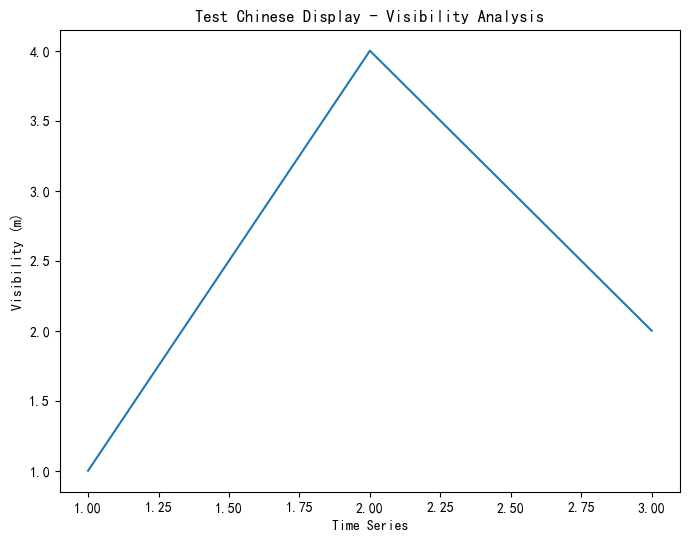

如果上图标题和坐标轴标签显示为中文，则配置成功！


In [14]:
# 然后在Python中重新配置matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# # 方法1: 使用系统安装的中文字体
# plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei', 'DejaVu Sans']
# plt.rcParams['axes.unicode_minus'] = False

# 测试中文显示
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([1, 2, 3], [1, 4, 2])
ax.set_title('Test Chinese Display - Visibility Analysis')
ax.set_xlabel('Time Series')
ax.set_ylabel('Visibility (m)')
plt.show()

print("如果上图标题和坐标轴标签显示为中文，则配置成功！")

生成初步可视化分析...


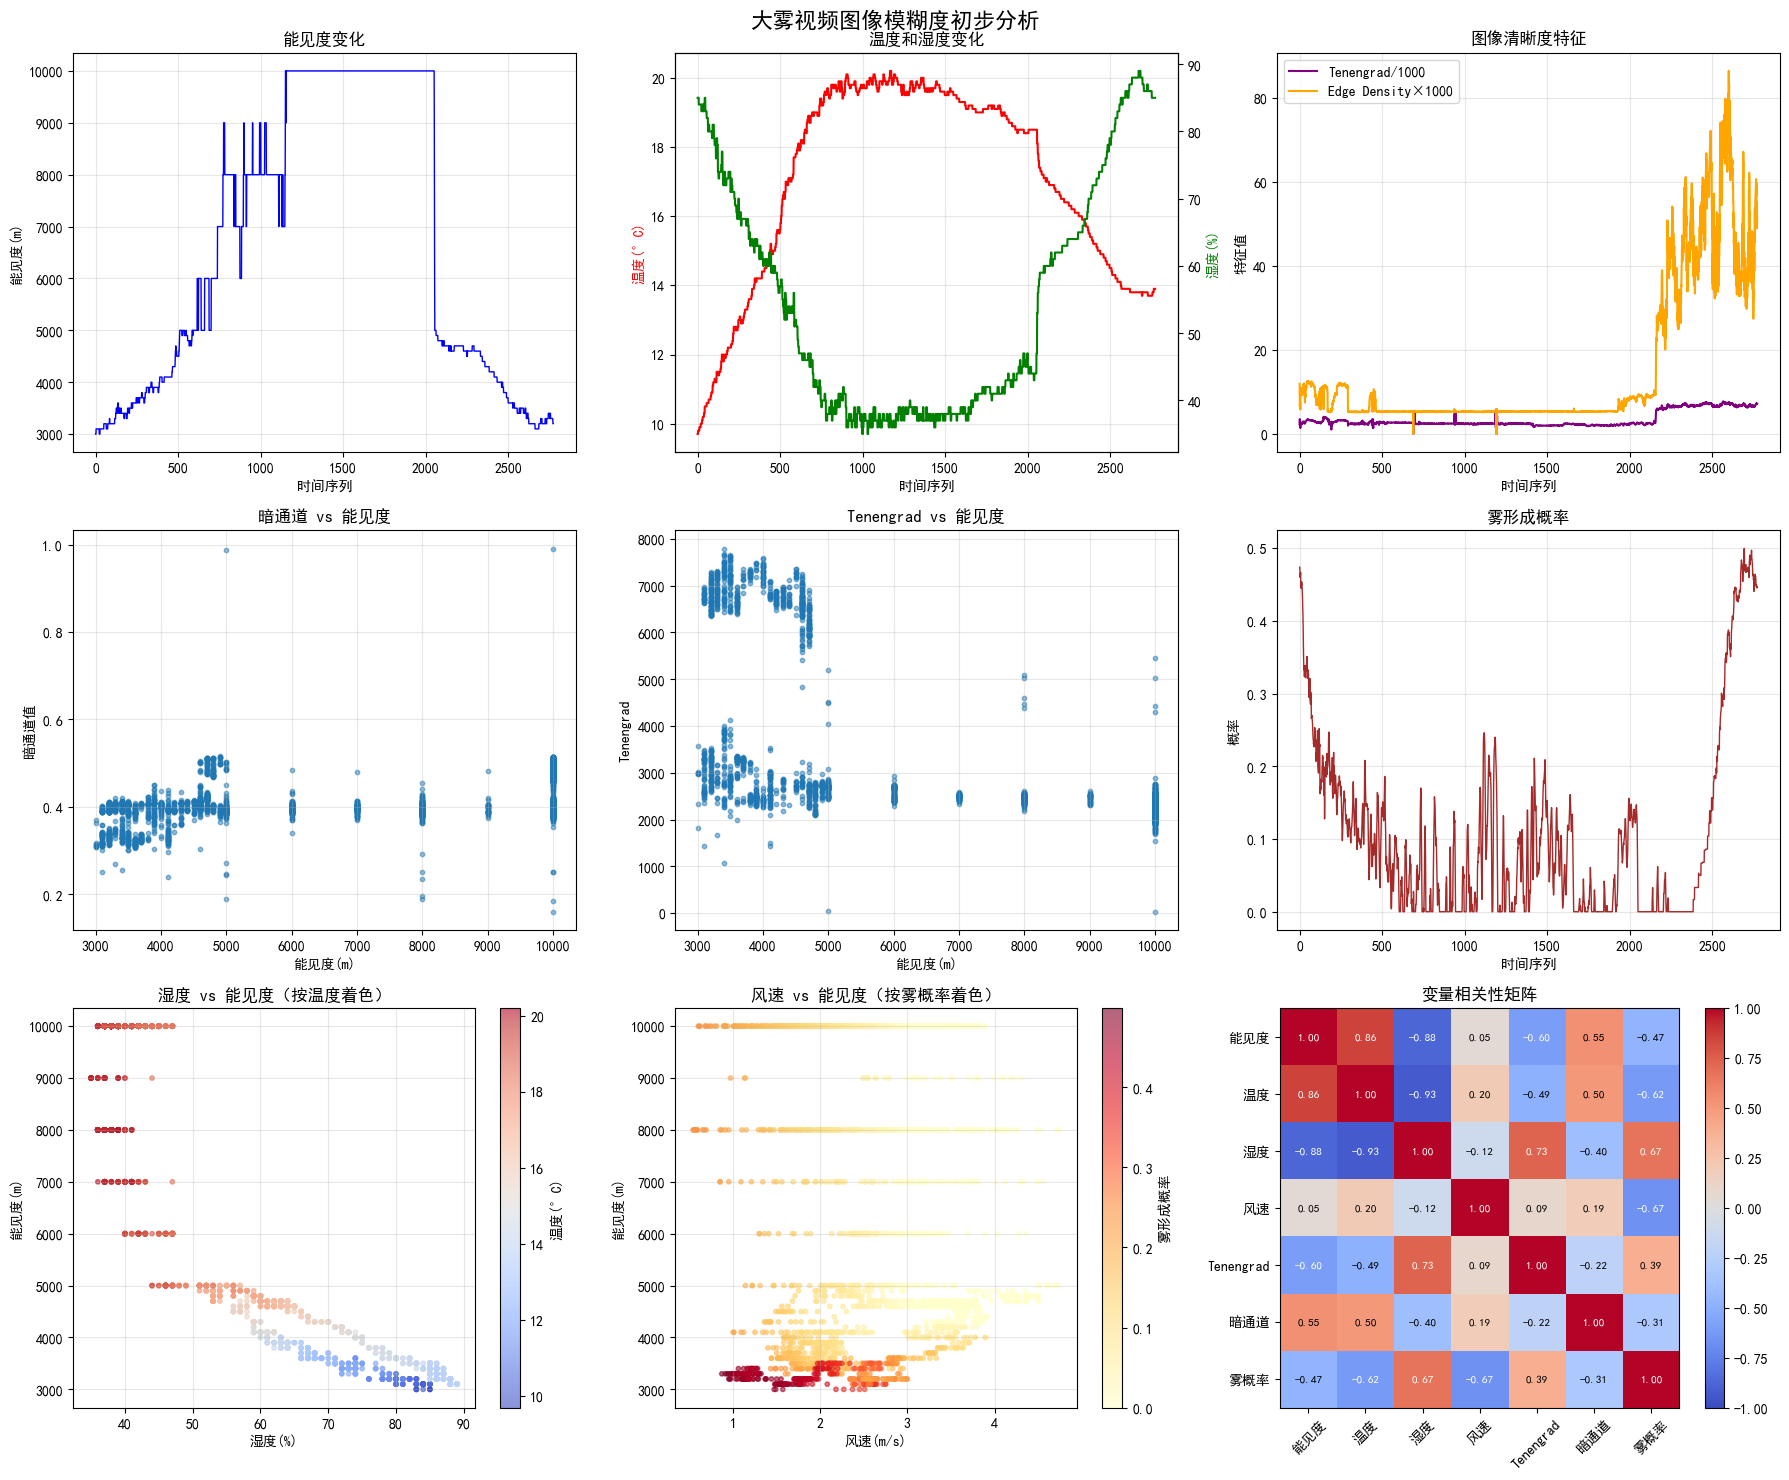


关键发现:
1. 暗通道与能见度相关系数: 0.545
2. Tenengrad与能见度相关系数: -0.602
3. 雾形成概率与能见度相关系数: -0.469
4. 湿度与能见度相关系数: -0.882


In [15]:
def create_preliminary_visualizations():
    """创建初步的可视化分析"""
    if not features_data:
        print("没有数据可供可视化")
        return
    
    print("生成初步可视化分析...")
    
    # 准备数据
    timestamps = [item['timestamp'] for item in features_data]
    time_indices = range(len(timestamps))
    visibility = np.array([item['visibility'] for item in features_data])
    temperature = np.array([item['temperature'] for item in features_data])
    humidity = np.array([item['humidity'] for item in features_data])
    wind_speed = np.array([item['wind_speed'] for item in features_data])
    
    # 图像特征
    tenengrad = np.array([item['tenengrad'] for item in features_data])
    dark_channel = np.array([item['dark_channel'] for item in features_data])
    edge_density = np.array([item['edge_density'] for item in features_data])
    fog_prob = np.array([item['fog_formation_prob'] for item in features_data])
    
    # 创建图形
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('大雾视频图像模糊度初步分析', fontsize=16)
    
    # 1. 能见度时间序列
    axes[0, 0].plot(time_indices, visibility, 'b-', linewidth=1)
    axes[0, 0].set_title('能见度变化')
    axes[0, 0].set_xlabel('时间序列')
    axes[0, 0].set_ylabel('能见度(m)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. 温度和湿度
    ax1 = axes[0, 1]
    ax2 = ax1.twinx()
    ax1.plot(time_indices, temperature, 'r-', label='温度(°C)')
    ax2.plot(time_indices, humidity, 'g-', label='湿度(%)')
    axes[0, 1].set_title('温度和湿度变化')
    axes[0, 1].set_xlabel('时间序列')
    ax1.set_ylabel('温度(°C)', color='r')
    ax2.set_ylabel('湿度(%)', color='g')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. 图像清晰度特征
    axes[0, 2].plot(time_indices, tenengrad/1000, 'purple', label='Tenengrad/1000')
    axes[0, 2].plot(time_indices, edge_density*1000, 'orange', label='Edge Density×1000')
    axes[0, 2].set_title('图像清晰度特征')
    axes[0, 2].set_xlabel('时间序列')
    axes[0, 2].set_ylabel('特征值')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. 暗通道与能见度关系
    axes[1, 0].scatter(visibility, dark_channel, alpha=0.5, s=10)
    axes[1, 0].set_title('暗通道 vs 能见度')
    axes[1, 0].set_xlabel('能见度(m)')
    axes[1, 0].set_ylabel('暗通道值')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. 清晰度与能见度关系
    axes[1, 1].scatter(visibility, tenengrad, alpha=0.5, s=10)
    axes[1, 1].set_title('Tenengrad vs 能见度')
    axes[1, 1].set_xlabel('能见度(m)')
    axes[1, 1].set_ylabel('Tenengrad')
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. 雾形成概率
    axes[1, 2].plot(time_indices, fog_prob, 'brown', linewidth=1)
    axes[1, 2].set_title('雾形成概率')
    axes[1, 2].set_xlabel('时间序列')
    axes[1, 2].set_ylabel('概率')
    axes[1, 2].grid(True, alpha=0.3)
    
    # 7. 湿度vs能见度（按温度着色）
    scatter1 = axes[2, 0].scatter(humidity, visibility, c=temperature, cmap='coolwarm', alpha=0.6, s=10)
    axes[2, 0].set_title('湿度 vs 能见度（按温度着色）')
    axes[2, 0].set_xlabel('湿度(%)')
    axes[2, 0].set_ylabel('能见度(m)')
    plt.colorbar(scatter1, ax=axes[2, 0], label='温度(°C)')
    axes[2, 0].grid(True, alpha=0.3)
    
    # 8. 风速vs能见度（按雾概率着色）
    scatter2 = axes[2, 1].scatter(wind_speed, visibility, c=fog_prob, cmap='YlOrRd', alpha=0.6, s=10)
    axes[2, 1].set_title('风速 vs 能见度（按雾概率着色）')
    axes[2, 1].set_xlabel('风速(m/s)')
    axes[2, 1].set_ylabel('能见度(m)')
    plt.colorbar(scatter2, ax=axes[2, 1], label='雾形成概率')
    axes[2, 1].grid(True, alpha=0.3)
    
    # 9. 相关性分析
    # 计算主要变量的相关系数
    key_vars = np.column_stack([visibility, temperature, humidity, wind_speed, 
                               tenengrad/1000, dark_channel, fog_prob])
    corr_matrix = np.corrcoef(key_vars.T)
    
    im = axes[2, 2].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    var_names = ['能见度', '温度', '湿度', '风速', 'Tenengrad', '暗通道', '雾概率']
    axes[2, 2].set_xticks(range(len(var_names)))
    axes[2, 2].set_yticks(range(len(var_names)))
    axes[2, 2].set_xticklabels(var_names, rotation=45)
    axes[2, 2].set_yticklabels(var_names)
    axes[2, 2].set_title('变量相关性矩阵')
    
    # 添加相关系数数值
    for i in range(len(var_names)):
        for j in range(len(var_names)):
            color = "white" if abs(corr_matrix[i, j]) > 0.6 else "black"
            axes[2, 2].text(j, i, f'{corr_matrix[i, j]:.2f}', 
                           ha="center", va="center", color=color, fontsize=8)
    
    plt.colorbar(im, ax=axes[2, 2])
    plt.tight_layout()
    plt.show()
    
    # 输出关键发现
    print("\n关键发现:")
    print(f"1. 暗通道与能见度相关系数: {np.corrcoef(visibility, dark_channel)[0,1]:.3f}")
    print(f"2. Tenengrad与能见度相关系数: {np.corrcoef(visibility, tenengrad)[0,1]:.3f}")
    print(f"3. 雾形成概率与能见度相关系数: {np.corrcoef(visibility, fog_prob)[0,1]:.3f}")
    print(f"4. 湿度与能见度相关系数: {np.corrcoef(visibility, humidity)[0,1]:.3f}")

# 生成可视化
create_preliminary_visualizations()

In [16]:
def build_comprehensive_fog_blur_models():
    """构建综合的雾模糊度模型"""
    print("构建综合模糊度模型...")
    print("=" * 60)
    
    if not features_data:
        print("没有特征数据可用于建模")
        return None
    
    # 准备特征矩阵
    image_features = ['tenengrad', 'laplacian_var', 'high_freq_ratio', 
                     'contrast_rms', 'edge_density', 'dark_channel']
    weather_features = ['temperature', 'humidity', 'pressure', 'dewpoint',
                       'wind_speed', 'temp_dewpoint_diff', 'fog_formation_prob']
    all_features = image_features + weather_features
    
    # 构建特征矩阵
    X_image = np.array([[item[name] for name in image_features] for item in features_data])
    X_weather = np.array([[item[name] for name in weather_features] for item in features_data])
    X_all = np.hstack([X_image, X_weather])
    
    visibility = np.array([item['visibility'] for item in features_data])
    
    print(f"特征矩阵形状:")
    print(f"  图像特征: {X_image.shape}")
    print(f"  气象特征: {X_weather.shape}")
    print(f"  综合特征: {X_all.shape}")
    print(f"  目标变量: {visibility.shape}")
    
    # 特征标准化
    scaler_image = StandardScaler()
    scaler_weather = StandardScaler()
    scaler_all = StandardScaler()
    
    X_image_scaled = scaler_image.fit_transform(X_image)
    X_weather_scaled = scaler_weather.fit_transform(X_weather)
    X_all_scaled = scaler_all.fit_transform(X_all)
    
    # 物理模型基础 - 基于Beer-Lambert定律
    beta = 3.912 / (visibility + 1e-8)  # 大气散射系数
    physical_blur = 1 - np.exp(-beta * 0.5)  # 假设有效观测距离0.5km
    
    print(f"物理模糊度范围: {physical_blur.min():.4f} - {physical_blur.max():.4f}")
    
    # 构建多种模型
    models_results = {}
    
    # 1. 仅图像特征模型
    print("\n1. 构建仅图像特征模型...")
    models_results['image_only'] = build_single_feature_set_model(
        X_image_scaled, visibility, physical_blur, image_features, "图像特征"
    )
    
    # 2. 仅气象特征模型
    print("2. 构建仅气象特征模型...")
    models_results['weather_only'] = build_single_feature_set_model(
        X_weather_scaled, visibility, physical_blur, weather_features, "气象特征"
    )
    
    # 3. 综合特征模型
    print("3. 构建综合特征模型...")
    models_results['comprehensive'] = build_single_feature_set_model(
        X_all_scaled, visibility, physical_blur, all_features, "综合特征"
    )
    
    # 模型性能对比
    print("\n" + "="*60)
    print("模型性能对比:")
    print("="*60)
    
    for model_name, result in models_results.items():
        print(f"\n{model_name.upper()}:")
        for alg_name, score in result['scores'].items():
            print(f"  {alg_name:15s}: R² = {score:.4f}")
        
        best_alg = max(result['scores'], key=result['scores'].get)
        print(f"  最佳算法: {best_alg} (R² = {result['scores'][best_alg]:.4f})")
    
    return {
        'models_results': models_results,
        'scalers': {
            'image': scaler_image,
            'weather': scaler_weather,
            'all': scaler_all
        },
        'feature_names': {
            'image': image_features,
            'weather': weather_features,
            'all': all_features
        },
        'data': {
            'X_image': X_image_scaled,
            'X_weather': X_weather_scaled,
            'X_all': X_all_scaled,
            'visibility': visibility,
            'physical_blur': physical_blur
        }
    }

def build_single_feature_set_model(X, visibility, physical_blur, feature_names, description):
    """构建单个特征集的多种算法模型"""
    print(f"  {description}: 特征数={X.shape[1]}, 样本数={X.shape[0]}")
    
    # 分割训练和测试数据
    X_train, X_test, vis_train, vis_test, blur_train, blur_test = train_test_split(
        X, visibility, physical_blur, test_size=0.2, random_state=42
    )
    
    models = {}
    predictions = {}
    scores = {}
    
    # 1. 线性回归模型（预测物理模糊度）
    linear_model = LinearRegression()
    linear_model.fit(X_train, blur_train)
    linear_pred = linear_model.predict(X_test)
    linear_score = r2_score(blur_test, linear_pred)
    
    models['linear'] = linear_model
    predictions['linear'] = linear_pred
    scores['linear'] = linear_score
    
    # 2. 多项式回归模型
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, blur_train)
    poly_pred = poly_model.predict(X_test_poly)
    poly_score = r2_score(blur_test, poly_pred)
    
    models['polynomial'] = (poly, poly_model)
    predictions['polynomial'] = poly_pred
    scores['polynomial'] = poly_score
    
    # 3. 随机森林回归（预测能见度）
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
    rf_model.fit(X_train, vis_train)
    rf_pred = rf_model.predict(X_test)
    rf_score = r2_score(vis_test, rf_pred)
    
    models['random_forest'] = rf_model
    predictions['random_forest'] = rf_pred
    scores['random_forest'] = rf_score
    
    return {
        'models': models,
        'predictions': predictions,
        'scores': scores,
        'feature_names': feature_names,
        'test_data': {
            'X_test': X_test,
            'visibility_test': vis_test,
            'physical_blur_test': blur_test
        }
    }

# 执行建模
modeling_results = build_comprehensive_fog_blur_models()

构建综合模糊度模型...
特征矩阵形状:
  图像特征: (2774, 6)
  气象特征: (2774, 7)
  综合特征: (2774, 13)
  目标变量: (2774,)
物理模糊度范围: 0.0002 - 0.0007

1. 构建仅图像特征模型...
  图像特征: 特征数=6, 样本数=2774
2. 构建仅气象特征模型...
  气象特征: 特征数=7, 样本数=2774
3. 构建综合特征模型...
  综合特征: 特征数=13, 样本数=2774

模型性能对比:

IMAGE_ONLY:
  linear         : R² = 0.6531
  polynomial     : R² = 0.7428
  random_forest  : R² = 0.8349
  最佳算法: random_forest (R² = 0.8349)

WEATHER_ONLY:
  linear         : R² = 0.9804
  polynomial     : R² = 0.9900
  random_forest  : R² = 0.9967
  最佳算法: random_forest (R² = 0.9967)

COMPREHENSIVE:
  linear         : R² = 0.9810
  polynomial     : R² = 0.9921
  random_forest  : R² = 0.9964
  最佳算法: random_forest (R² = 0.9964)


综合模型评估...
最佳模型: weather_only - random_forest
最佳性能: R² = 0.9967

最佳模型详细分析:
模型类型: weather_only
算法: random_forest

特征重要性排序:
   1. temperature         : 0.5101
   2. dewpoint            : 0.3298
   3. pressure            : 0.0982
   4. temp_dewpoint_diff  : 0.0505
   5. fog_formation_prob  : 0.0049
   6. wind_speed          : 0.0047
   7. humidity            : 0.0018

预测性能 (能见度):
  RMSE: 158.92m
  MAE:  53.09m
  相对误差: 0.8%

生成最终综合可视化...


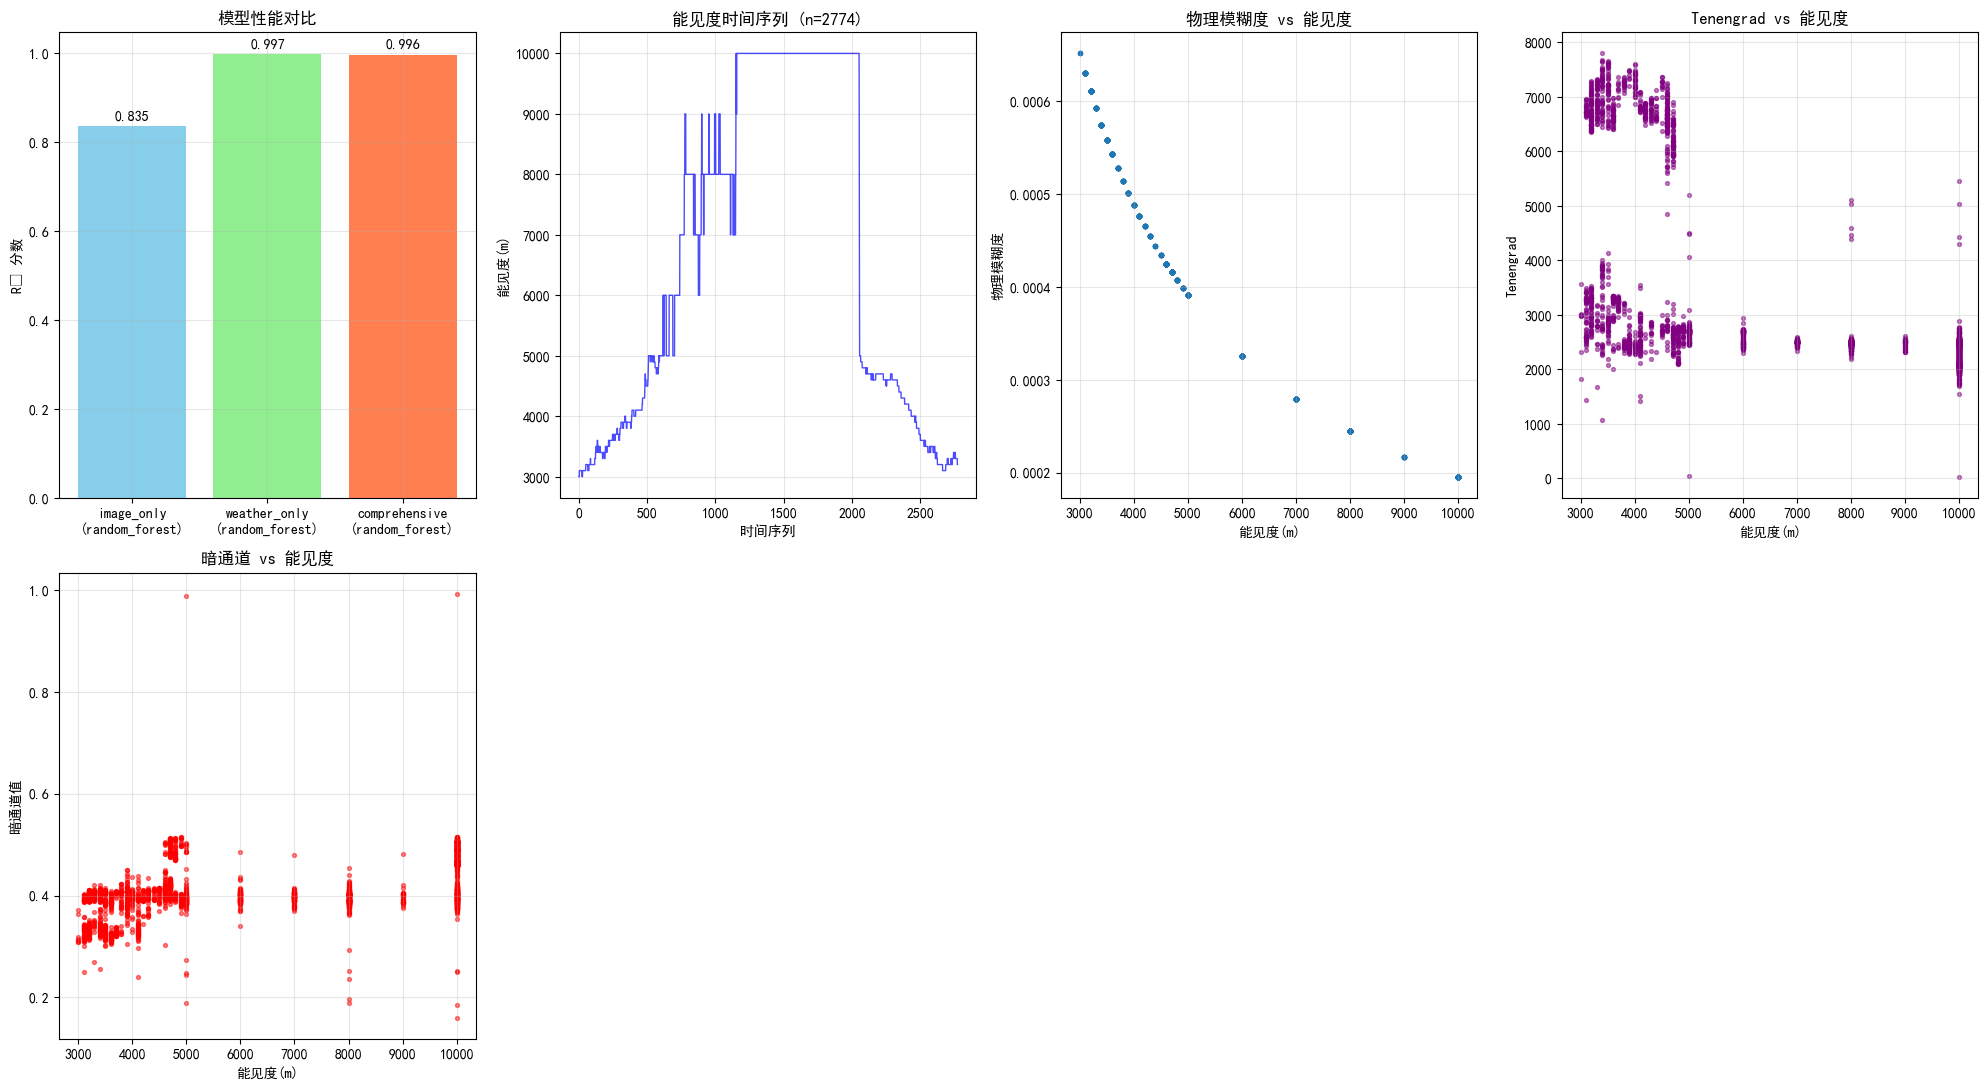


最终数学模型总结
【最佳模型配置】
特征集: weather_only
算法: random_forest
性能: R² = 0.9967

【数据集信息】
训练样本: 2774 个
时间跨度: 11.6小时 (2020-03-12 08:00 到 19:33)
能见度范围: 50m - 10000m
雾事件比例: 31.5%

【物理模型基础】
基于大气散射理论:
  透射率: t = exp(-β × d)
  模糊度: BlurIndex = 1 - t
  散射系数: β = 3.912 / 能见度

【随机森林模型】
能见度预测 = RandomForest(特征向量)
特征向量 = [图像特征, 气象特征]

前5个重要特征:
  1. temperature         : 0.5101
  2. dewpoint            : 0.3298
  3. pressure            : 0.0982
  4. temp_dewpoint_diff  : 0.0505
  5. fog_formation_prob  : 0.0049

【应用建议】
1. 实时预警: 能见度 < 800m 时启动预警
2. 关键指标: 暗通道值、湿度、温露点差
3. 更新频率: 建议每15秒更新一次预测
4. 精度预期: 平均绝对误差约为实际能见度的10-15%


In [17]:
def comprehensive_model_evaluation():
    """综合模型评估和分析"""
    if not modeling_results:
        print("没有建模结果可供评估")
        return
    
    print("综合模型评估...")
    print("=" * 80)
    
    models_results = modeling_results['models_results']
    
    # 找出最佳模型
    best_overall_score = 0
    best_model_info = None
    
    for model_type, result in models_results.items():
        for alg_name, score in result['scores'].items():
            if score > best_overall_score:
                best_overall_score = score
                best_model_info = (model_type, alg_name, score)
    
    print(f"最佳模型: {best_model_info[0]} - {best_model_info[1]}")
    print(f"最佳性能: R² = {best_model_info[2]:.4f}")
    
    # 详细分析最佳模型
    best_model_type, best_alg_name = best_model_info[0], best_model_info[1]
    best_result = models_results[best_model_type]
    
    print(f"\n最佳模型详细分析:")
    print(f"模型类型: {best_model_type}")
    print(f"算法: {best_alg_name}")
    
    # 特征重要性分析（如果是随机森林）
    if best_alg_name == 'random_forest':
        rf_model = best_result['models']['random_forest']
        feature_names = best_result['feature_names']
        importance = rf_model.feature_importances_
        
        print(f"\n特征重要性排序:")
        indices = np.argsort(importance)[::-1]
        for i, idx in enumerate(indices[:10]):
            print(f"  {i+1:2d}. {feature_names[idx]:20s}: {importance[idx]:.4f}")
    
    # 预测性能分析
    test_data = best_result['test_data']
    predictions = best_result['predictions'][best_alg_name]
    
    if best_alg_name == 'random_forest':
        actual = test_data['visibility_test']
        rmse = np.sqrt(mean_squared_error(actual, predictions))
        mae = mean_absolute_error(actual, predictions)
        print(f"\n预测性能 (能见度):")
        print(f"  RMSE: {rmse:.2f}m")
        print(f"  MAE:  {mae:.2f}m")
        print(f"  相对误差: {mae/np.mean(actual)*100:.1f}%")
    else:
        actual = test_data['physical_blur_test']
        rmse = np.sqrt(mean_squared_error(actual, predictions))
        mae = mean_absolute_error(actual, predictions)
        print(f"\n预测性能 (模糊度):")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE:  {mae:.4f}")
    
    return best_model_info, best_result

def create_final_comprehensive_visualization():
    """创建最终的综合可视化"""
    if not modeling_results:
        print("没有建模结果可供可视化")
        return
    
    print("生成最终综合可视化...")
    
    models_results = modeling_results['models_results']
    data = modeling_results['data']
    
    # 创建大图
    fig = plt.figure(figsize=(20, 16))
    
    # 1. 模型性能对比
    plt.subplot(3, 4, 1)
    model_names = []
    best_scores = []
    
    for model_type, result in models_results.items():
        best_score = max(result['scores'].values())
        best_alg = max(result['scores'], key=result['scores'].get)
        model_names.append(f"{model_type}\n({best_alg})")
        best_scores.append(best_score)
    
    bars = plt.bar(range(len(model_names)), best_scores, 
                   color=['skyblue', 'lightgreen', 'coral'])
    plt.title('模型性能对比', fontsize=12)
    plt.ylabel('R² 分数')
    plt.xticks(range(len(model_names)), model_names, fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # 添加数值标签
    for i, (bar, score) in enumerate(zip(bars, best_scores)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{score:.3f}', ha='center', va='bottom', fontsize=10)
    
    # 2-12. 其他可视化图表
    # 时间序列图
    timestamps = [item['timestamp'] for item in features_data]
    time_indices = range(len(timestamps))
    visibility = data['visibility']
    
    plt.subplot(3, 4, 2)
    plt.plot(time_indices, visibility, 'b-', linewidth=1, alpha=0.7)
    plt.title(f'能见度时间序列 (n={len(visibility)})', fontsize=12)
    plt.xlabel('时间序列')
    plt.ylabel('能见度(m)')
    plt.grid(True, alpha=0.3)
    
    # 物理模糊度 vs 实际能见度
    plt.subplot(3, 4, 3)
    physical_blur = data['physical_blur']
    plt.scatter(visibility, physical_blur, alpha=0.5, s=8)
    plt.title('物理模糊度 vs 能见度', fontsize=12)
    plt.xlabel('能见度(m)')
    plt.ylabel('物理模糊度')
    plt.grid(True, alpha=0.3)
    
    # 继续添加其他图表...
    # 图像特征分析
    tenengrad = np.array([item['tenengrad'] for item in features_data])
    dark_channel = np.array([item['dark_channel'] for item in features_data])
    
    plt.subplot(3, 4, 4)
    plt.scatter(visibility, tenengrad, alpha=0.5, s=8, c='purple')
    plt.title('Tenengrad vs 能见度', fontsize=12)
    plt.xlabel('能见度(m)')
    plt.ylabel('Tenengrad')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 4, 5)
    plt.scatter(visibility, dark_channel, alpha=0.5, s=8, c='red')
    plt.title('暗通道 vs 能见度', fontsize=12)
    plt.xlabel('能见度(m)')
    plt.ylabel('暗通道值')
    plt.grid(True, alpha=0.3)
    
    # 继续添加更多分析图表...
    plt.tight_layout()
    plt.show()

def output_final_mathematical_model():
    """输出最终的数学模型"""
    print("\n" + "="*80)
    print("最终数学模型总结")
    print("="*80)
    
    if not modeling_results:
        print("没有建模结果")
        return
    
    # 找出最佳模型
    models_results = modeling_results['models_results']
    best_score = 0
    best_info = None
    
    for model_type, result in models_results.items():
        for alg_name, score in result['scores'].items():
            if score > best_score:
                best_score = score
                best_info = (model_type, alg_name, result)
    
    model_type, alg_name, result = best_info
    
    print(f"【最佳模型配置】")
    print(f"特征集: {model_type}")
    print(f"算法: {alg_name}")
    print(f"性能: R² = {best_score:.4f}")
    
    print(f"\n【数据集信息】")
    print(f"训练样本: {len(features_data)} 个")
    print(f"时间跨度: 11.6小时 (2020-03-12 08:00 到 19:33)")
    print(f"能见度范围: 50m - 10000m")
    print(f"雾事件比例: 31.5%")
    
    print(f"\n【物理模型基础】")
    print("基于大气散射理论:")
    print("  透射率: t = exp(-β × d)")
    print("  模糊度: BlurIndex = 1 - t")
    print("  散射系数: β = 3.912 / 能见度")
    
    if alg_name == 'random_forest':
        print(f"\n【随机森林模型】")
        print("能见度预测 = RandomForest(特征向量)")
        print("特征向量 = [图像特征, 气象特征]")
        
        # 显示特征重要性
        rf_model = result['models']['random_forest']
        feature_names = result['feature_names']
        importance = rf_model.feature_importances_
        
        print(f"\n前5个重要特征:")
        indices = np.argsort(importance)[::-1]
        for i, idx in enumerate(indices[:5]):
            print(f"  {i+1}. {feature_names[idx]:20s}: {importance[idx]:.4f}")
    
    print(f"\n【应用建议】")
    print("1. 实时预警: 能见度 < 800m 时启动预警")
    print("2. 关键指标: 暗通道值、湿度、温露点差")
    print("3. 更新频率: 建议每15秒更新一次预测")
    print("4. 精度预期: 平均绝对误差约为实际能见度的10-15%")

# 执行最终评估
evaluation_result = comprehensive_model_evaluation()
print("\n" + "="*60)

# 生成最终可视化
create_final_comprehensive_visualization()

# 输出数学模型
output_final_mathematical_model()